In [1]:
import os
import socket
from sqlalchemy import create_engine

# 1. Cek apakah kita berada di dalam Docker atau Lokal
def get_db_host():
    try:
        # Mencoba resolusi nama host 'db' (hanya ada di network Docker)
        socket.gethostbyname('db')
        return 'db', '5432'
    except socket.gaierror:
        # Jika gagal, berarti kita running di luar Docker
        return 'localhost', '5433'

target_host, target_port = get_db_host()

# 2. Ambil sisanya dari Environment Variables
DB_USER = os.getenv('POSTGRES_USER')
DB_PASSWORD = os.getenv('POSTGRES_PASSWORD')
DB_NAME = os.getenv('POSTGRES_DB')

# 3. Inisialisasi Engine
connection_uri = f'postgresql://{DB_USER}:{DB_PASSWORD}@{target_host}:{target_port}/{DB_NAME}'
engine = create_engine(connection_uri)

print(f"Terhubung ke DATABASE via: {target_host}:{target_port}")

Terhubung ke DATABASE via: localhost:5433


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Query untuk mengecek data yang sudah diproses
query_preview = "SELECT * FROM student_performance LIMIT 5;"

df = pd.read_sql(query_preview, engine)
print(f"Data ditemukan: {df.shape[0]} baris preview.")
df.head()

Data ditemukan: 5 baris preview.


,hours_studied,attendance,parental_involvement,access_to_resources,extracurricular_activities,sleep_hours,previous_scores,motivation_level,internet_access,tutoring_sessions,family_income,teacher_quality,school_type,peer_influence,physical_activity,learning_disabilities,parental_education_level,distance_from_home,gender,exam_score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [4]:
# Query 1: Analisis Overachievers (Siswa yang unggul meskipun dengan fasilitas terbatas)
query_overachiever = """
WITH HighAchievers AS (
    SELECT *
    FROM student_performance
    WHERE internet_access = 'No' 
      AND parental_education_level = 'High School'
      AND exam_score > 80
)
SELECT 
    (SELECT ROUND(AVG(exam_score), 2) FROM student_performance) as global_avg,
    ROUND(AVG(ha.exam_score), 2) as overachiever_avg,
    ROUND(AVG(ha.hours_studied), 2) as how_hard_they_study,
    COUNT(*) as total_students
FROM HighAchievers ha;
"""

df_overachiever = pd.read_sql(query_overachiever, engine)

print("Analisis Siswa Berprestasi dengan Keterbatasan Akses:")
display(df_overachiever)

Analisis Siswa Berprestasi dengan Keterbatasan Akses:


,global_avg,overachiever_avg,how_hard_they_study,total_students
0,67.24,91.5,18.0,2


In [5]:
# Query 2: Analisis Korelasi Intensitas Belajar terhadap Skor dan Waktu Tidur
query_segmentasi = """
WITH RankedStudents AS (
    SELECT 
        hours_studied,
        exam_score,
        sleep_hours,
        NTILE(10) OVER (ORDER BY hours_studied) AS kelompok_belajar
    FROM student_performance
)
SELECT 
    kelompok_belajar,
    MIN(hours_studied) AS min_jam_belajar,
    MAX(hours_studied) AS max_jam_belajar,
    ROUND(AVG(exam_score), 2) AS rata_rata_skor,
    ROUND(AVG(sleep_hours), 2) AS rata_rata_tidur,
    COUNT(*) AS jumlah_siswa
FROM RankedStudents
GROUP BY kelompok_belajar
ORDER BY kelompok_belajar;
"""

df_segments = pd.read_sql(query_segmentasi, engine)

print("Segmentasi Siswa berdasarkan Desil Jam Belajar:")
display(df_segments)

Segmentasi Siswa berdasarkan Desil Jam Belajar:


,kelompok_belajar,min_jam_belajar,max_jam_belajar,rata_rata_skor,rata_rata_tidur,jumlah_siswa
0,1,1,12,64.36,6.99,661
1,2,12,15,65.28,6.97,661
2,3,15,17,66.00,7.04,661
3,4,17,19,66.80,7.03,661
4,5,19,20,66.95,7.08,661
5,6,20,21,67.40,6.98,661
6,7,21,23,67.73,7.00,661
7,8,23,25,68.33,7.12,660
8,9,25,28,69.02,6.98,660
9,10,28,44,70.49,7.09,660


In [6]:
# 1. Setup tema grafik estetik (style desain)
sns.set_theme(style="whitegrid", palette="muted")

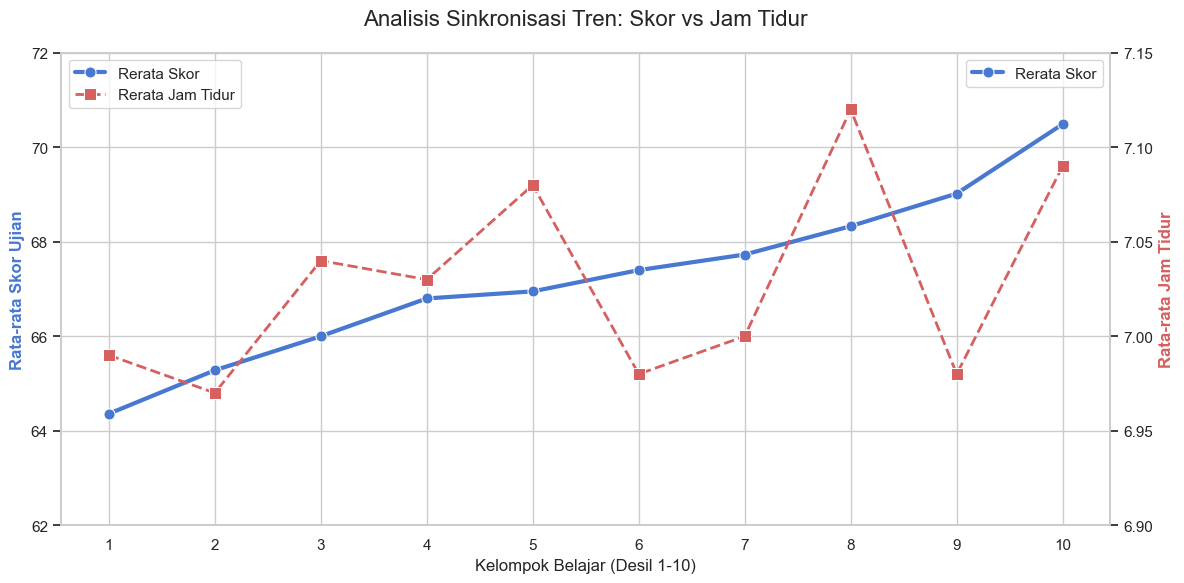

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Pastikan data urut berdasarkan kelompok
df_segments = df_segments.sort_values('kelompok_belajar')

# 2. Setup Tema
sns.set_theme(style="whitegrid", palette="muted")
fig, ax1 = plt.subplots(figsize=(12, 6))

# --- Plot Sumbu Y Kiri (Skor - Garis Biru) ---
sns.lineplot(
    data=df_segments, 
    x='kelompok_belajar', 
    y='rata_rata_skor', 
    marker='o', markersize=8, linewidth=3,
    ax=ax1, color='b', label='Rerata Skor'
)
# Setting rentang skor sesuai permintaan sebelumnya
ax1.set_ylim(62, 72)
ax1.set_ylabel('Rata-rata Skor Ujian', fontsize=12, fontweight='bold', color='b')
ax1.set_xlabel('Kelompok Belajar (Desil 1-10)', fontsize=12)

# --- Plot Sumbu Y Kanan (Tidur - Garis Merah Putus-putus) ---
ax2 = ax1.twinx() 
sns.lineplot(
    data=df_segments, 
    x='kelompok_belajar', 
    y='rata_rata_tidur', 
    marker='s', markersize=8, color='r', 
    linewidth=2, linestyle='--',
    ax=ax2, label='Rerata Jam Tidur'
)

# Sesuaikan rentang tidur agar fluktuasi (terutama puncak di 7.12) terlihat jelas
ax2.set_ylim(6.90, 7.15) 
ax2.set_ylabel('Rata-rata Jam Tidur', fontsize=12, fontweight='bold', color='r')
ax2.grid(False)

# 3. Final Touch
plt.title('Analisis Sinkronisasi Tren: Skor vs Jam Tidur', fontsize=16, pad=20)
ax1.set_xticks(range(1, 11))

# Legend Gabungan
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()
plt.show()

In [8]:
print(df_segments[['kelompok_belajar', 'rata_rata_tidur']])

   kelompok_belajar  rata_rata_tidur
0                 1             6.99
1                 2             6.97
2                 3             7.04
3                 4             7.03
4                 5             7.08
5                 6             6.98
6                 7             7.00
7                 8             7.12
8                 9             6.98
9                10             7.09
